In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from math import sqrt

In [3]:
df = pd.read_csv(".\data\heart.csv")
df

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [4]:
df_saturation = pd.read_csv(".\data\o2Saturation.csv", header = None)
df_saturation

,0
0,98.6
1,98.6
2,98.6
3,98.6
4,98.1
...,...
3581,98.6
3582,98.6
3583,98.6
3584,98.6


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trtbps    303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalachh  303 non-null    int64  
 8   exng      303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slp       303 non-null    int64  
 11  caa       303 non-null    int64  
 12  thall     303 non-null    int64  
 13  output    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [6]:
df[df['output'] == 0]

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
165,67,1,0,160,286,0,0,108,1,1.5,1,3,2,0
166,67,1,0,120,229,0,0,129,1,2.6,1,2,3,0
167,62,0,0,140,268,0,0,160,0,3.6,0,2,2,0
168,63,1,0,130,254,0,0,147,0,1.4,1,1,3,0
169,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [87]:
303 - 138

165

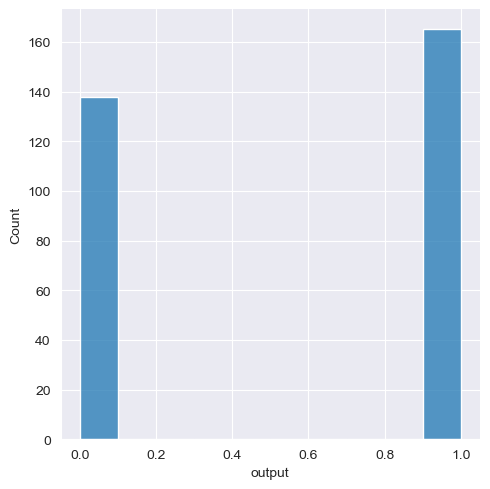

In [7]:
import seaborn as sns
sns.displot(df['output']);

In [8]:
df['Saturation 02'] = df_saturation
df

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output,Saturation 02
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1,98.6
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1,98.6
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1,98.6
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1,98.6
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1,98.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0,97.5
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0,97.5
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0,97.5
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0,97.5


In [9]:
df['output2'] = df['output'].values
df.drop(columns='output', inplace=True)

In [10]:
df

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,Saturation 02,output2
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,98.6,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,98.6,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,98.6,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,98.6,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,98.1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,97.5,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,97.5,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,97.5,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,97.5,0


In [11]:
import seaborn as sns

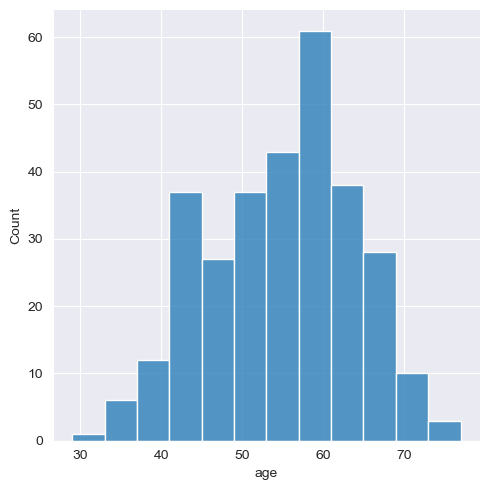

In [12]:
sns.displot(df['age']);

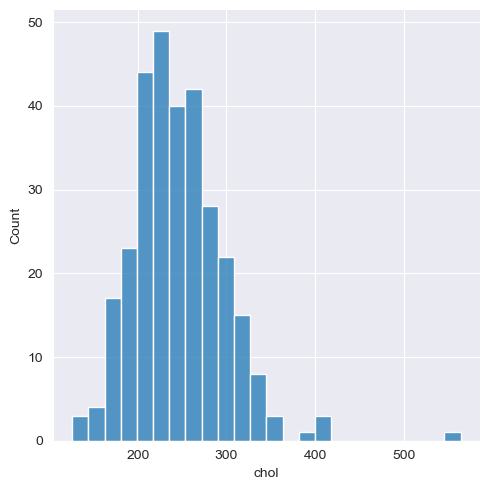

In [13]:
sns.displot(df['chol']);

In [14]:
np.min(df['chol']), np.max(df['chol'])

(126, 564)

In [15]:
df['chol'].describe()

count    303.000000
mean     246.264026
std       51.830751
min      126.000000
25%      211.000000
50%      240.000000
75%      274.500000
max      564.000000
Name: chol, dtype: float64

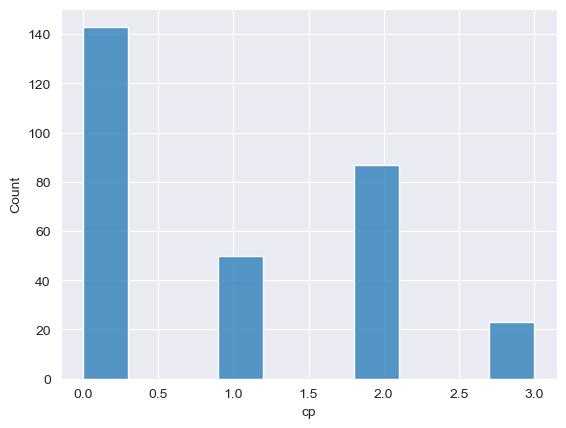

In [16]:
# Let's see the type of the chest pain

sns.histplot(df['cp']);


# We don't have type zero of chest pain
# Value 1: typical angina
# Value 2: atypical angina
# Value 3: non-anginal pain
# Value 4: asymptomatic

In [17]:
# 143 values like zero (0)
df[df['cp'].values == 0]

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,Saturation 02,output2
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,98.1,1
5,57,1,0,140,192,0,1,148,0,0.4,1,0,1,97.5,1
10,54,1,0,140,239,0,1,160,0,1.2,2,0,2,97.5,1
18,43,1,0,150,247,0,1,171,0,1.5,2,0,2,98.6,1
20,59,1,0,135,234,0,1,161,0,0.5,1,0,3,98.6,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
296,63,0,0,124,197,0,1,136,1,0.0,1,0,2,97.5,0
297,59,1,0,164,176,1,0,90,0,1.0,1,2,1,97.5,0
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,97.5,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,97.5,0


In [18]:
# 45 people had sugar level above 120mg/dL
df[df['fbs'].values == 1]

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,Saturation 02,output2
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,98.6,1
8,52,1,2,172,199,1,1,162,0,0.5,2,0,3,97.5,1
14,58,0,3,150,283,1,0,162,0,1.0,2,0,2,97.5,1
23,61,1,2,150,243,1,1,137,1,1.0,1,0,2,98.6,1
26,59,1,2,150,212,1,1,157,0,1.6,2,0,2,97.5,1
28,65,0,2,140,417,1,0,157,0,0.8,2,1,2,97.5,1
29,53,1,2,130,197,1,0,152,0,1.2,0,0,2,97.5,1
36,54,0,2,135,304,1,1,170,0,0.0,2,0,2,97.5,1
60,71,0,2,110,265,1,0,130,0,0.0,2,1,2,97.5,1
64,58,1,2,140,211,1,0,165,0,0.0,2,0,2,97.5,1


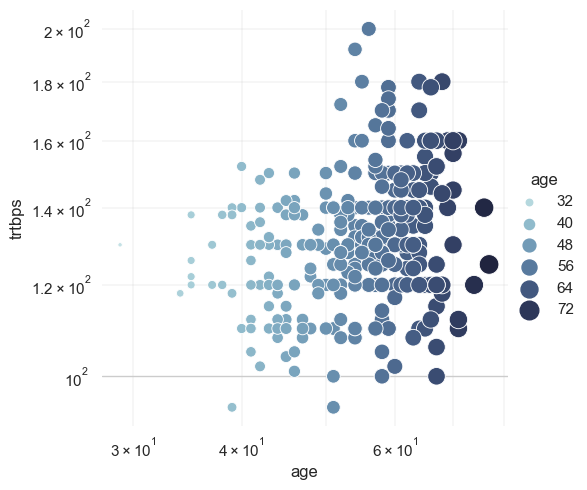

In [19]:
import matplotlib.pyplot as plt
sns.set_theme(style="whitegrid")

cmap = sns.cubehelix_palette(rot=-.2, as_cmap=True)
g = sns.relplot(
    data=df,
    x="age", y="trtbps", size='age',
    hue="age", palette=cmap, sizes=(10, 200),
)

g.set(xscale="log", yscale="log")
g.ax.xaxis.grid(True, "minor", linewidth=.25)
g.ax.yaxis.grid(True, "minor", linewidth=.25)
g.despine(left=True, bottom=True)

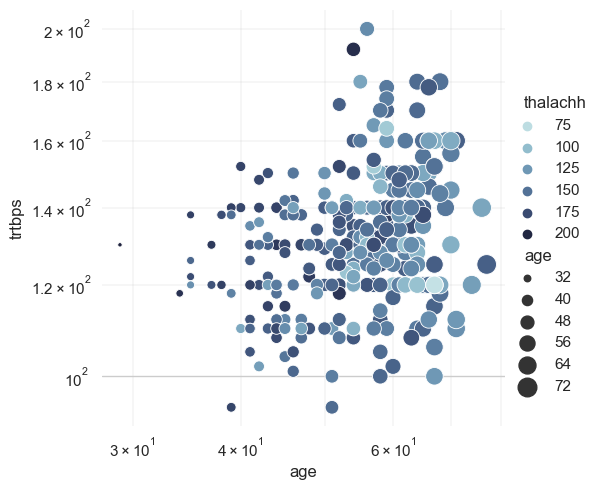

In [20]:
import matplotlib.pyplot as plt
sns.set_theme(style="whitegrid")

cmap = sns.cubehelix_palette(rot=-.2, as_cmap=True)
g = sns.relplot(
    data=df,
    x="age", y="trtbps", size='age',
    hue="thalachh", palette=cmap, sizes=(10, 200),
)

g.set(xscale="log", yscale="log")
g.ax.xaxis.grid(True, "minor", linewidth=.25)
g.ax.yaxis.grid(True, "minor", linewidth=.25)
g.despine(left=True, bottom=True)

C:\Users\Matheus\AppData\Local\Temp\ipykernel_13804\2081255575.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['exng']);


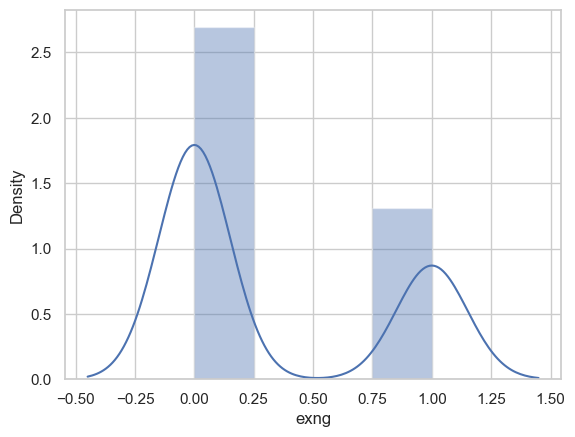

In [21]:
# how many people had angina induced by exercise?
# We observed less frequency of that particulary variable

sns.distplot(df['exng']);

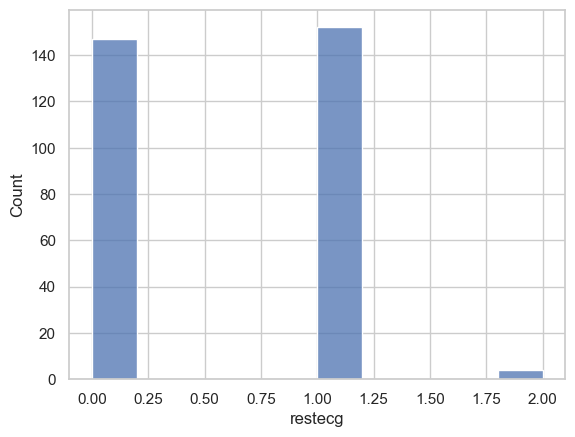

In [22]:
# How many of these people had a normal ECG?

sns.histplot(df['restecg']);

<Axes: xlabel='Saturation 02', ylabel='age'>

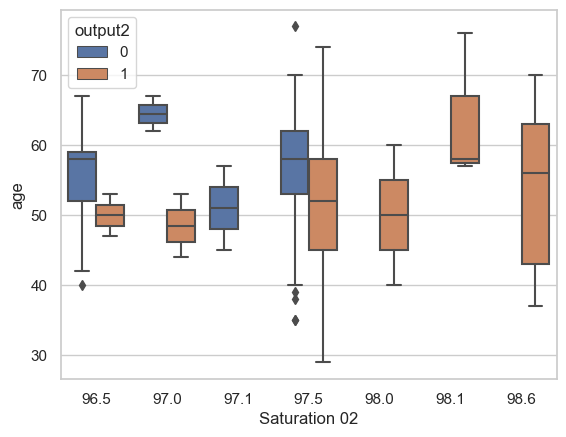

In [23]:
sns.boxplot(data=df, x="Saturation 02", y="age", hue="output2")

In [25]:
# Building the X and y variables

X = df.iloc[:, 0:15].values
X

array([[0.81818182, 1.        , 1.        , ..., 0.33333333, 1.        ,
        1.        ],
       [0.48051948, 1.        , 0.66666667, ..., 0.66666667, 1.        ,
        1.        ],
       [0.53246753, 0.        , 0.33333333, ..., 0.66666667, 1.        ,
        1.        ],
       ...,
       [0.88311688, 1.        , 0.        , ..., 1.        , 0.98884381,
        0.        ],
       [0.74025974, 1.        , 0.        , ..., 1.        , 0.98884381,
        0.        ],
       [0.74025974, 0.        , 0.33333333, ..., 0.66666667, 0.98884381,
        0.        ]])

In [26]:
y = df.iloc[:, -1].values
y

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=40)
print(X_train.shape); print(X_test.shape)

(242, 15)
(61, 15)


In [28]:
from sklearn.neural_network import MLPClassifier

In [46]:
clf = MLPClassifier(random_state=1, max_iter=10, verbose=True).fit(X_train, y_train) ;
previsoes = clf.predict(X_test) ;
previsoes

Iteration 1, loss = 0.69481977
Iteration 2, loss = 0.67553130
Iteration 3, loss = 0.65749249
Iteration 4, loss = 0.64050749
Iteration 5, loss = 0.62405204
Iteration 6, loss = 0.60832080
Iteration 7, loss = 0.59307162
Iteration 8, loss = 0.57840749
Iteration 9, loss = 0.56394208
Iteration 10, loss = 0.55008393


C:\Users\Matheus\anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(


array([1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1,
       1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0,
       1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1], dtype=int64)

In [47]:
acuracia = clf.score(X_test, y_test)
acuracia

0.8852459016393442

In [49]:
!pip install yellowbrick

  Using cached yellowbrick-1.5-py3-none-any.whl (282 kB)

[notice] A new release of pip available: 22.1.2 -> 23.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [52]:
!python.exe -m pip install --upgrade pip

  Using cached pip-23.0.1-py3-none-any.whl (2.1 MB)
  Attempting uninstall: pip
    Found existing installation: pip 22.1.2
    Uninstalling pip-22.1.2:
      Successfully uninstalled pip-22.1.2
  Rolling back uninstall of pip
  Moving to c:\users\matheus\appdata\roaming\python\python310\scripts\
   from C:\Users\Matheus\AppData\Roaming\Python\Python310\~cripts
  Moving to c:\users\matheus\appdata\roaming\python\python310\site-packages\pip-22.1.2.dist-info\
   from C:\Users\Matheus\AppData\Roaming\Python\Python310\site-packages\~ip-22.1.2.dist-info
  Moving to c:\users\matheus\appdata\roaming\python\python310\site-packages\pip\
   from C:\Users\Matheus\AppData\Roaming\Python\Python310\site-packages\~ip

[notice] A new release of pip available: 22.1.2 -> 23.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


ERROR: Exception:
Traceback (most recent call last):
  File "C:\Users\Matheus\AppData\Roaming\Python\Python310\site-packages\pip\_internal\cli\base_command.py", line 167, in exc_logging_wrapper
    status = run_func(*args)
  File "C:\Users\Matheus\AppData\Roaming\Python\Python310\site-packages\pip\_internal\cli\req_command.py", line 205, in wrapper
    return func(self, options, args)
  File "C:\Users\Matheus\AppData\Roaming\Python\Python310\site-packages\pip\_internal\commands\install.py", line 407, in run
    installed = install_given_reqs(
  File "C:\Users\Matheus\AppData\Roaming\Python\Python310\site-packages\pip\_internal\req\__init__.py", line 73, in install_given_reqs
    requirement.install(
  File "C:\Users\Matheus\AppData\Roaming\Python\Python310\site-packages\pip\_internal\req\req_install.py", line 773, in install
    install_wheel(
  File "C:\Users\Matheus\AppData\Roaming\Python\Python310\site-packages\pip\_internal\operations\install\wheel.py", line 730, in install_wheel
 

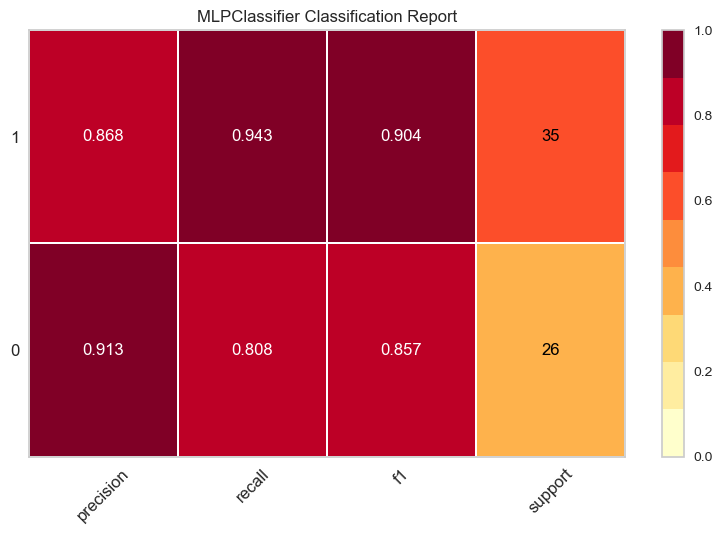

<Axes: title={'center': 'MLPClassifier Classification Report'}>

In [53]:
from yellowbrick.classifier import ClassificationReport

visualizer = ClassificationReport(clf, support=True)

visualizer.fit(X_train, y_train)        # Fit the visualizer and the model
visualizer.score(X_test, y_test)        # Evaluate the model on the test data
visualizer.show()